In [1]:
import psychometric_fxns as pf
import psignifit as ps
import psignifit.psigniplot as psp
import matplotlib.pyplot as plt

In [3]:
import os

repo_dir = os.getcwd()
data_dir = os.path.join(repo_dir, 'tilt_mocs','data')
#loop thru subjects (only the directories that start with sub there are no letters after sub just numbers, so not sub-eliza but yes sub-21040096)
all_subs = [d for d in os.listdir(data_dir) if d.startswith('sub-') and d[4:].isdigit()]
#get the subs whose IDs are greater than or equal to 21049995
stair_subs = [d for d in all_subs if int(d[4:]) >= 21049995]
#get the subs whose IDs are less than 21049995
fixed_subs = [d for d in all_subs if int(d[4:]) < 21049995]

# Collect all subject data
data_files = {}
for sub in fixed_subs:
    sub_data_dir = os.path.join(data_dir, sub, 'ses-0')
    csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')]
    if csv_files:
        data_files[sub] = os.path.join(sub_data_dir, csv_files[0])


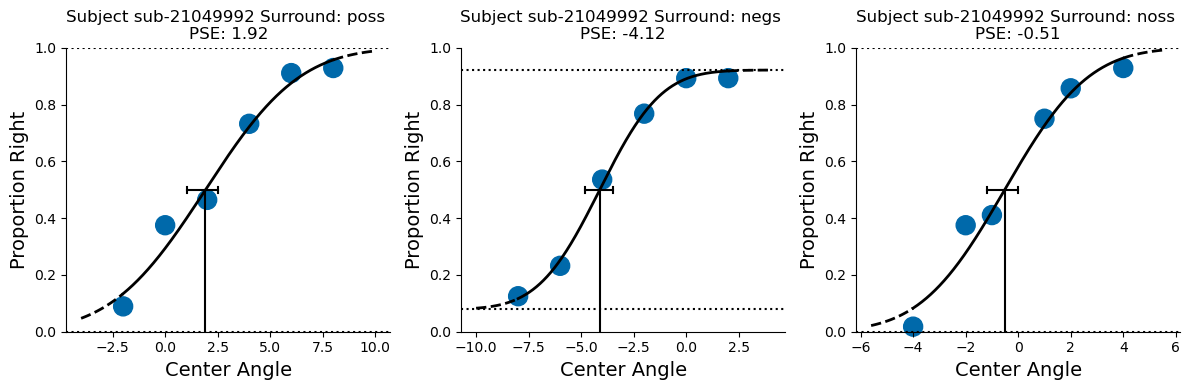

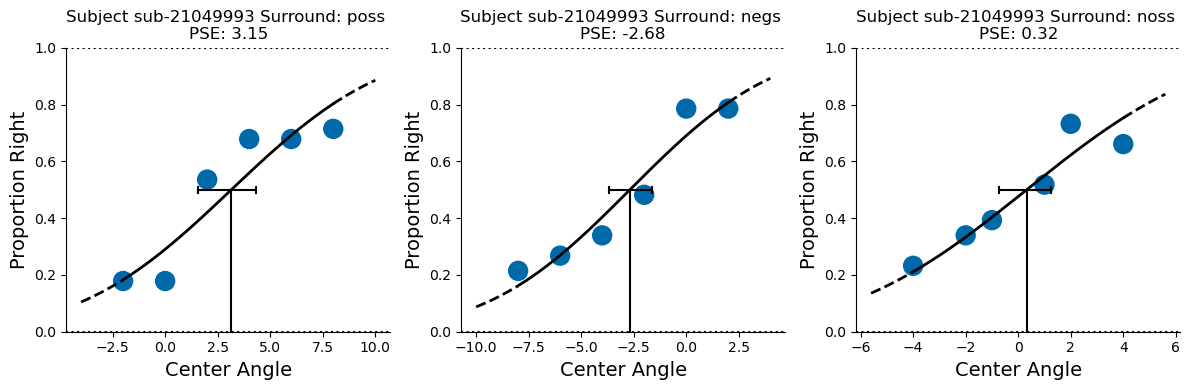

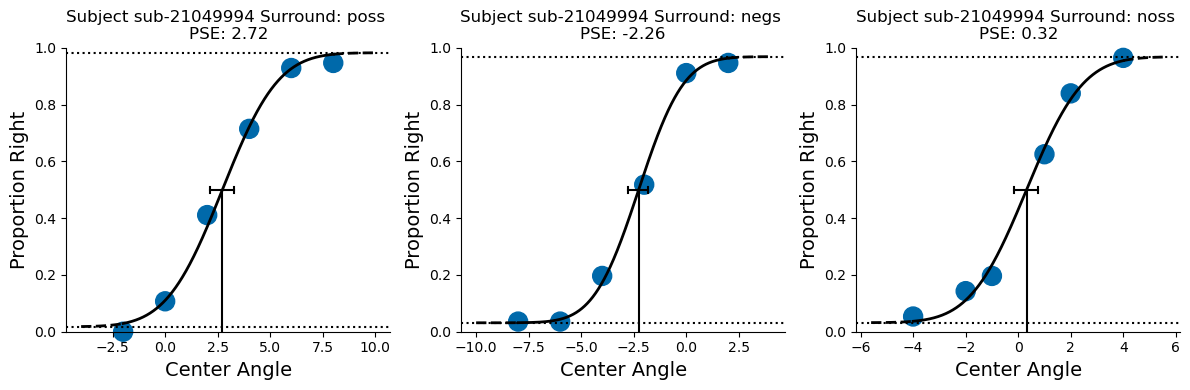

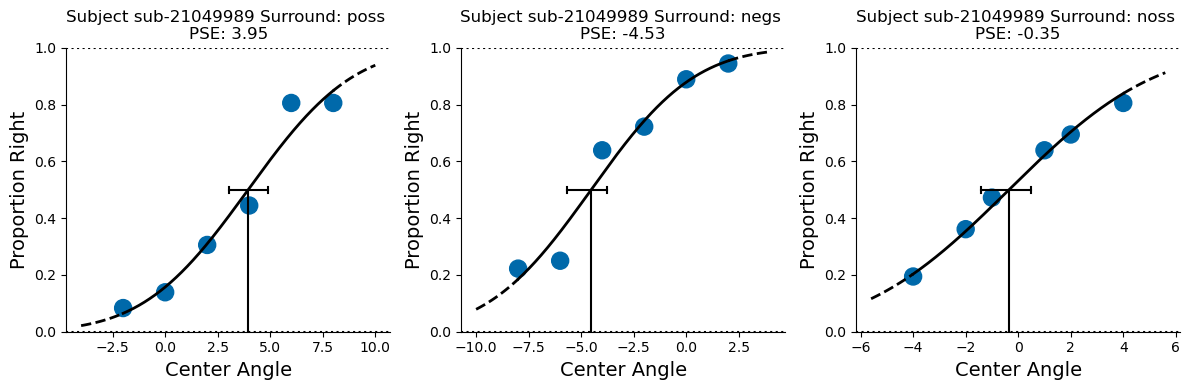

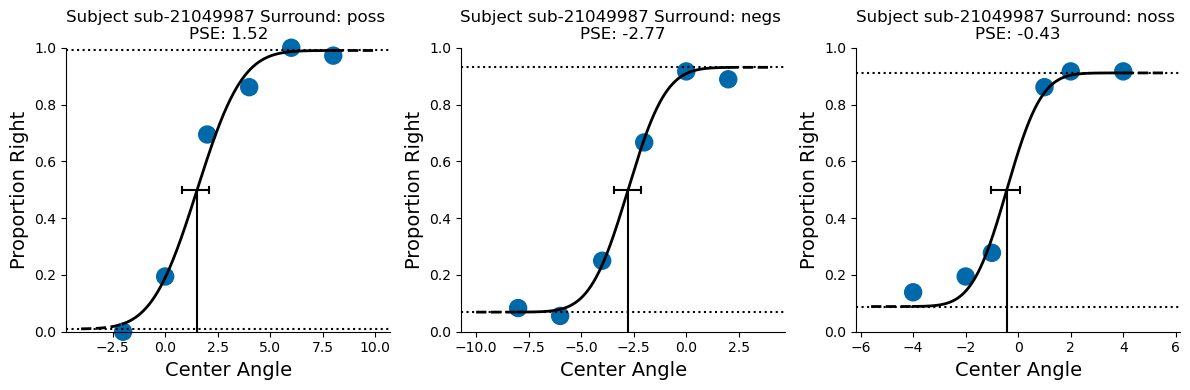

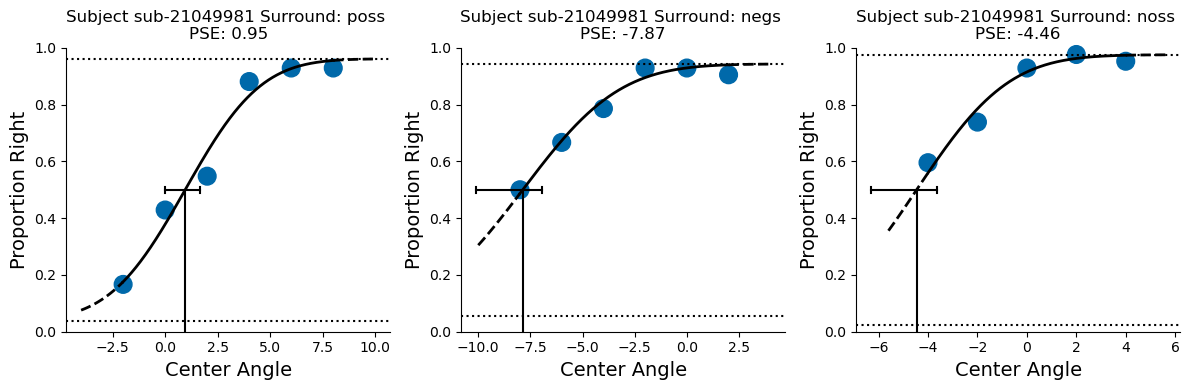

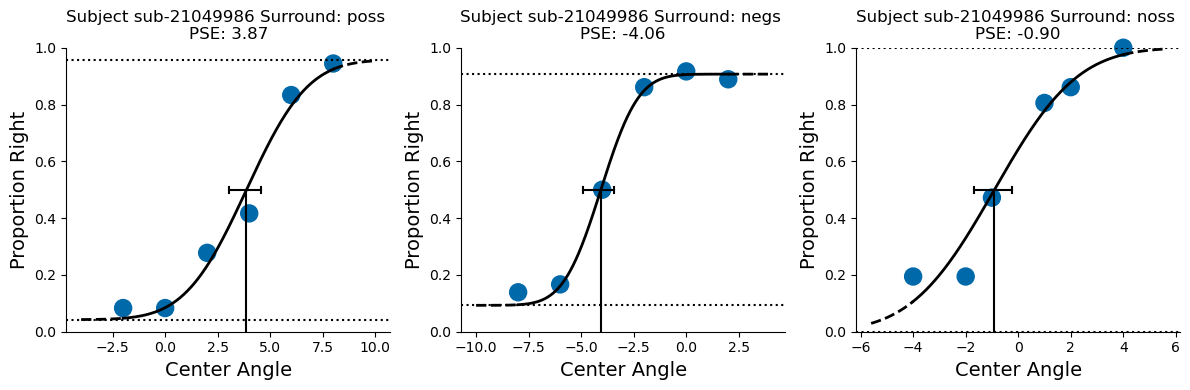

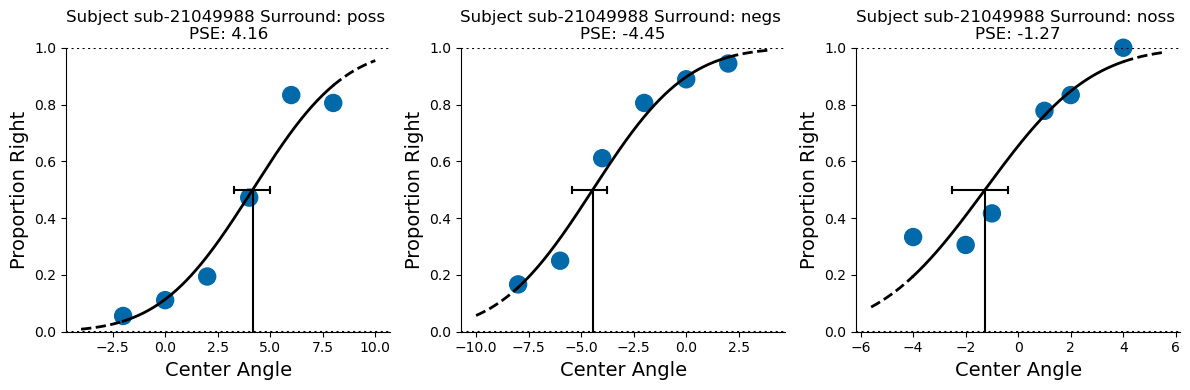

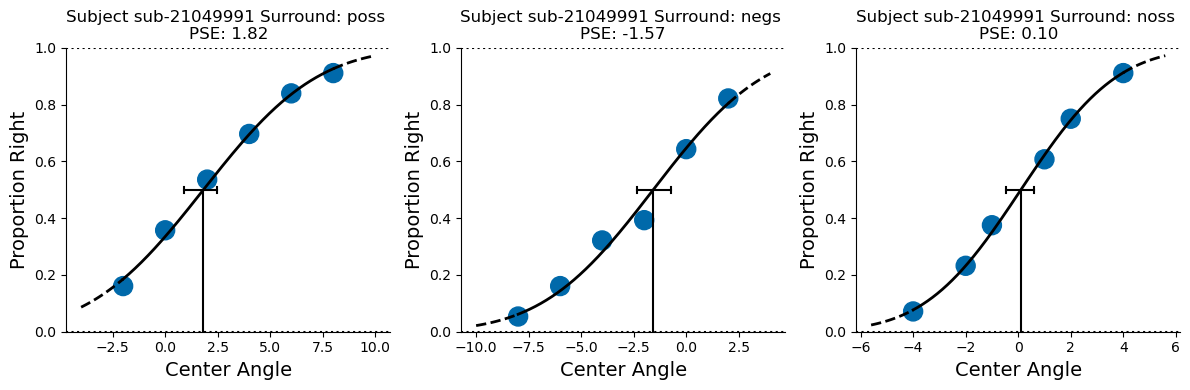

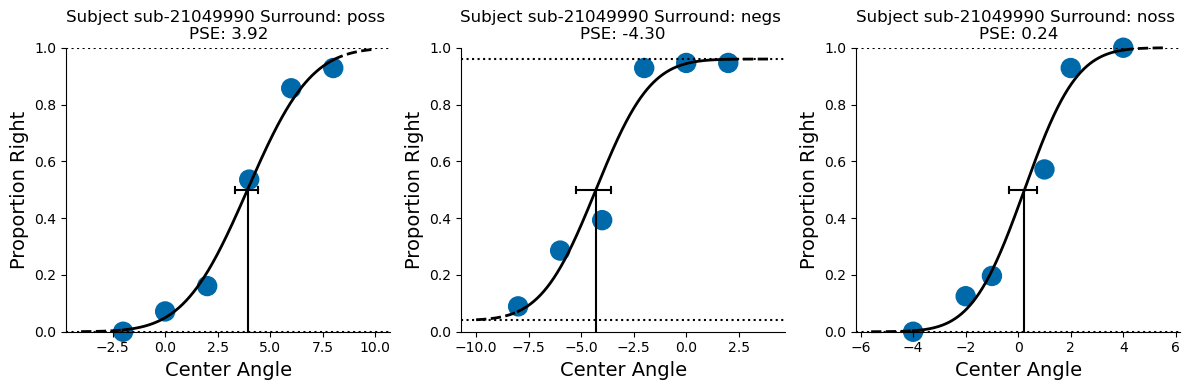

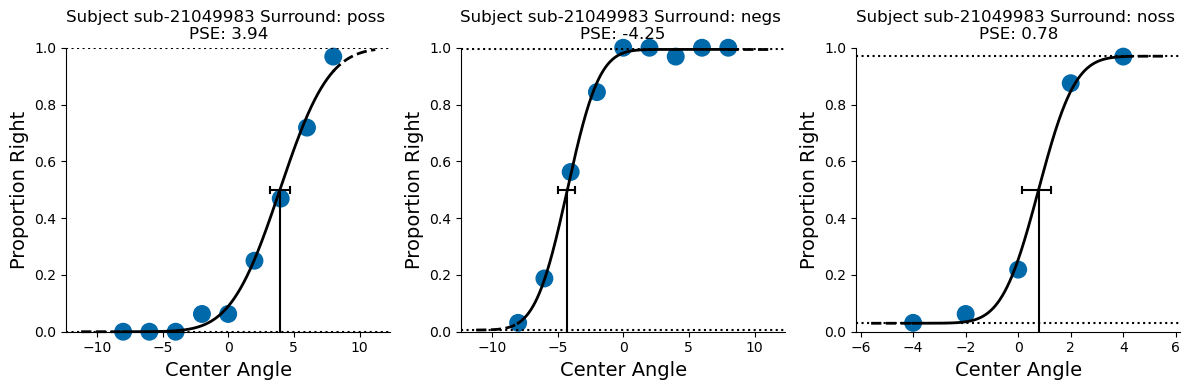

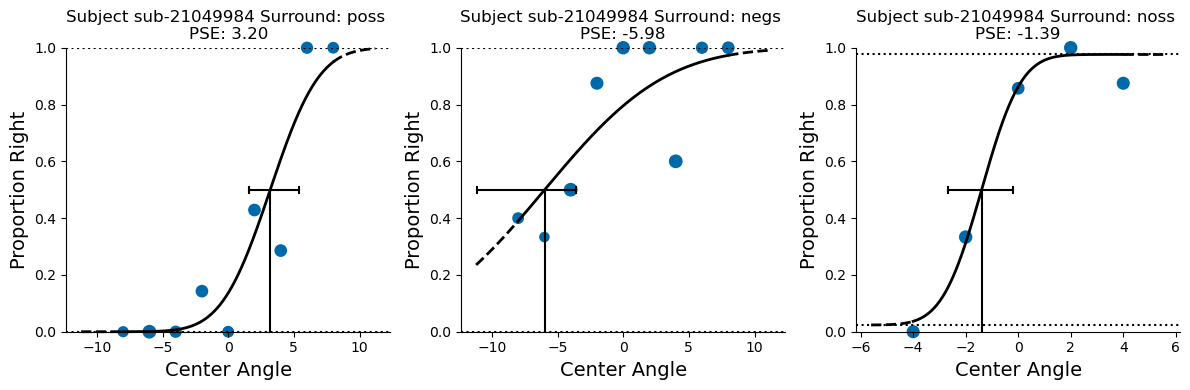

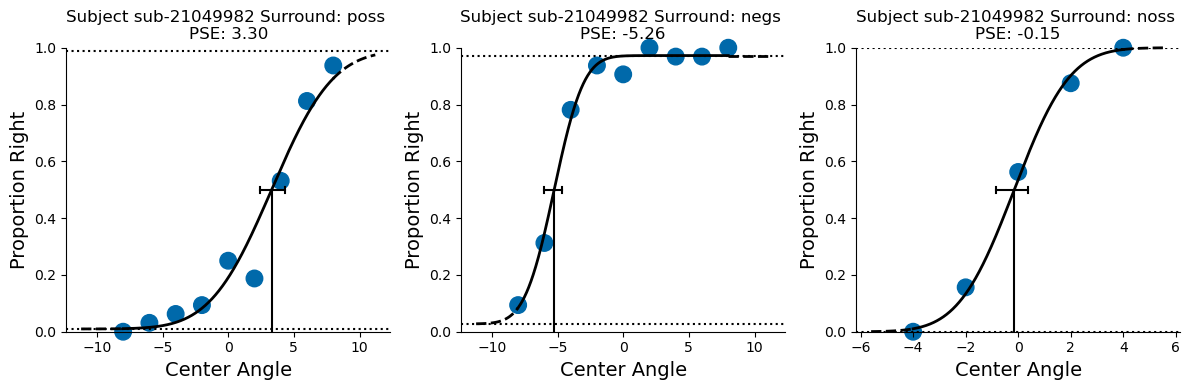

In [4]:
# plot each subject's psychometric function individually (already there)
# also create a mega plot with all of the individual plots on one figure
for sub, file_path in data_files.items():
    test = pf.get_psignifit_data_from_mocs_csv(file_path)
    fit_results = pf.fit_psychometric_fxn(test)
    pf.plot_psychometric_fxns(fit_results, sub)
    plt.show()

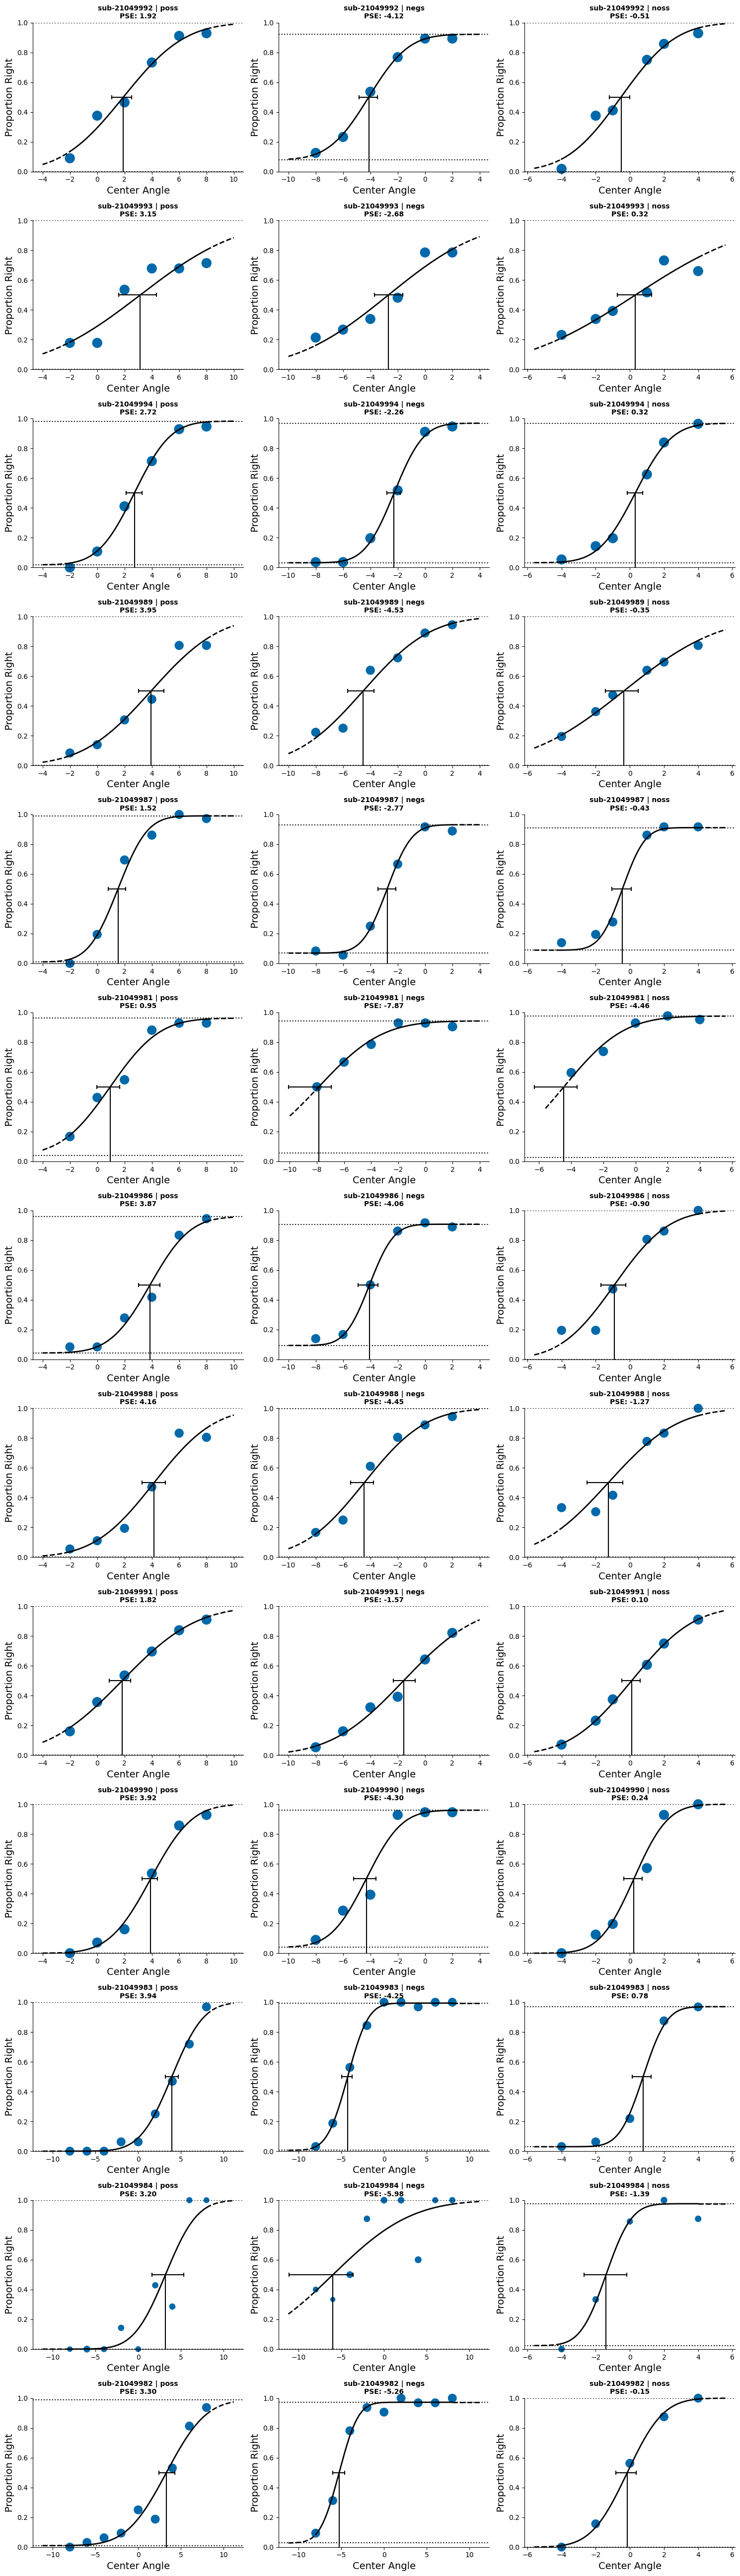

In [5]:
import numpy as np

# Create mega plot with one big figure
n_subs = len(data_files)
n_cols = 3  # 3 surround conditions per subject
n_rows = n_subs

fig = plt.figure(figsize=(15, 4*n_rows))

plot_idx = 1
for sub, file_path in data_files.items():
    test = pf.get_psignifit_data_from_mocs_csv(file_path)
    fit_results = pf.fit_psychometric_fxn(test)
    
    # Plot each surround type
    for i, surround_cond in enumerate(['poss', 'negs', 'noss']):
        ax = plt.subplot(n_rows, n_cols, plot_idx)
        fit_result = fit_results[surround_cond]
        psp.plot_psychometric_function(fit_result)
        
        pse = fit_result.parameter_estimate['threshold']
        ax.set_title(f'{sub} | {surround_cond}\nPSE: {pse:.2f}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Center Angle')
        ax.set_ylabel('Proportion Right')
        
        plot_idx += 1

plt.tight_layout()
plt.savefig('psychometric_functions_all_subjects.png', dpi=300, bbox_inches='tight')
plt.show()

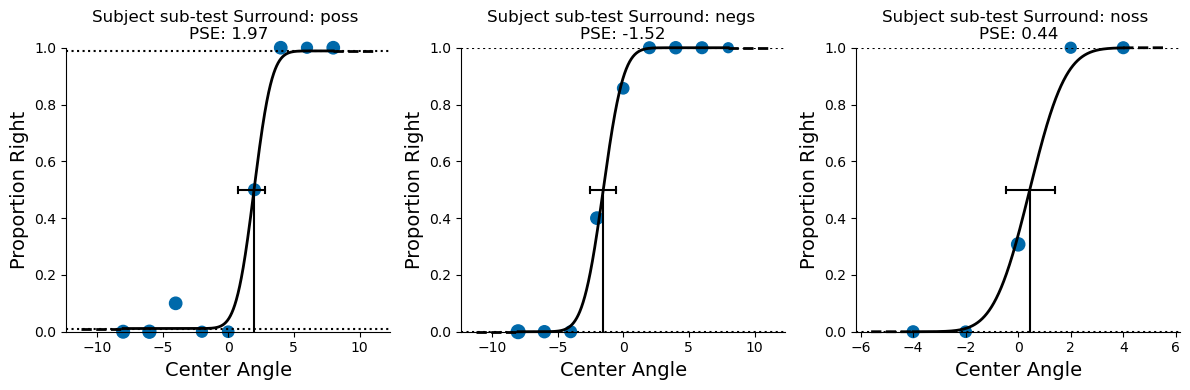

In [2]:
result = pf.get_psignifit_data_from_mocs_csv('/Users/bwinsto2/Documents/Documents - BV-PCR-VPJVMF3/Github/tilt/tilt_mocs/data/sub-test/ses-0/sub-test_ses-0_exp-tiltmocs_2025-12-10_17h32.53.562.csv')
output = pf.fit_psychometric_fxn(result)
pf.plot_psychometric_fxns(output, 'sub-test')
plt.show()